Starting the plant disease classification process using InceptionV3...
Dataset already extracted!
Loading data...
Found 32572 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Found 10885 images belonging to 38 classes.
Creating InceptionV3 model...
Starting training...
Epoch 1/3
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.7116 - loss: 1.1162

1018/1018 ━━━━━━━━━━━━━━━━━━━━ 857s 798ms/step - accuracy: 0.7117 - loss: 1.1157 - val_accuracy: 0.9545 - val_loss: 0.1403 - learning_rate: 7.5580e-04
Epoch 2/3
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.9345 - loss: 0.2094

1018/1018 ━━━━━━━━━━━━━━━━━━━━ 782s 768ms/step - accuracy: 0.9345 - loss: 0.2094 - val_accuracy: 0.9759 - val_loss: 0.0738 - learning_rate: 2.5589e-04
Epoch 3/3
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.9668 - loss: 0.1000

1018/1018 ━━━━━━━━━━━━━━━━━━━━ 784s 770ms/step - accuracy: 0.9668 - loss: 0.1000 - val_accuracy: 0.9864 - val_loss: 0.0447 - learning_rate: 1.4479e-07
341/341 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - accuracy: 0.9884 - loss: 0.0363


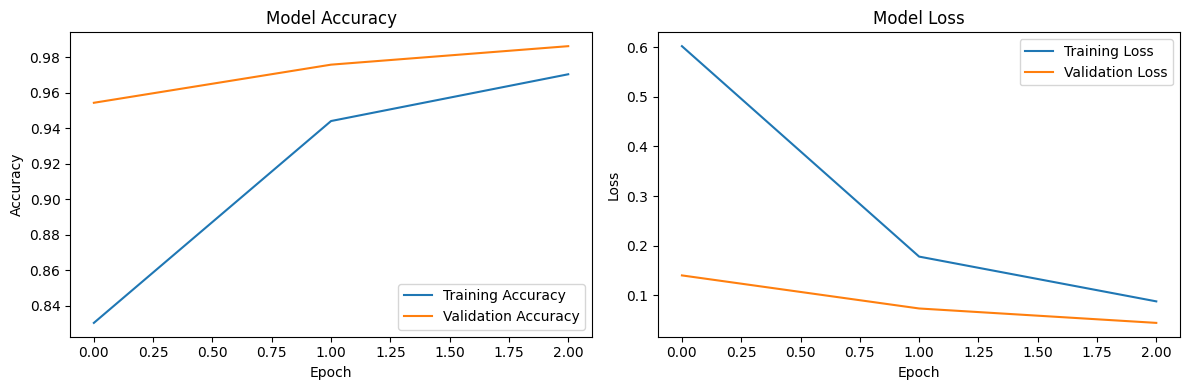

341/341 ━━━━━━━━━━━━━━━━━━━━ 47s 119ms/step


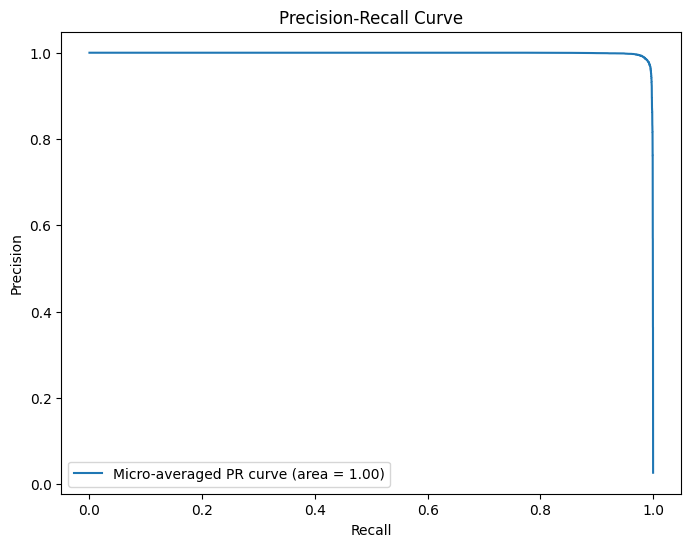


Final Accuracies:
Training Accuracy: 0.9705
Validation Accuracy: 0.9864
Testing Accuracy: 0.9863


In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
from sklearn.metrics import precision_recall_curve, auc

# Enable mixed precision training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def extract_dataset():
    zip_path = "/content/drive/MyDrive/Copy of PLANT_VILLAGE_SPLIT (1).zip"
    extract_path = "/content/plant_village"

    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete!")
    else:
        print("Dataset already extracted!")
    return extract_path

def create_inception_model(num_classes=38, trainable_layers=100):
    # Load InceptionV3 without top layer
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )

    # Freeze initial layers
    for layer in base_model.layers[:-trainable_layers]:
        layer.trainable = False

    # Unfreeze final layers for fine-tuning
    for layer in base_model.layers[-trainable_layers:]:
        layer.trainable = True

    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    # First Dense layer
    x = Dense(1024, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # Second Dense layer
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Output layer
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def load_data(base_path, img_size=(299, 299)):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        brightness_range=[0.8, 1.2]
    )

    valid_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'train'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=True
    )

    validation_generator = valid_datagen.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'val'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = valid_datagen.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'test'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, validation_generator, test_generator

def train_and_evaluate():
    base_path = extract_dataset()
    print("Loading data...")
    train_generator, val_generator, test_generator = load_data(base_path)
    num_classes = len(train_generator.class_indices)

    print("Creating InceptionV3 model...")
    model = create_inception_model(num_classes=num_classes)

    # Learning rate schedule
    initial_learning_rate = 0.001
    decay_steps = train_generator.n // train_generator.batch_size * 3
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate,
        decay_steps,
        alpha=0.0001
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            mode='max'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_inception_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max'
        )
    ]

    print("Starting training...")
    history = model.fit(
        train_generator,
        epochs=3,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    # Load best weights
    model.load_weights('best_inception_model.h5')

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(test_generator)

    # Plot results
    plot_training_results(history, model, test_generator, num_classes)

    return (history.history['accuracy'][-1],
            history.history['val_accuracy'][-1],
            test_accuracy)

def plot_training_results(history, model, test_generator, num_classes):
    # Plot accuracy and loss curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Generate predictions for PR curve
    y_pred = model.predict(test_generator)
    y_test = test_generator.labels
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

    # Plot PR curve
    plt.figure(figsize=(8, 6))
    precision = dict()
    recall = dict()

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_pred[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test.ravel(), y_pred.ravel())

    plt.plot(recall["micro"], precision["micro"],
             label=f'Micro-averaged PR curve (area = {auc(recall["micro"], precision["micro"]):.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    print("Starting the plant disease classification process using InceptionV3...")
    train_acc, val_acc, test_acc = train_and_evaluate()
    print(f"\nFinal Accuracies:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")